In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Coin Flip Tutorial Bayesian Inference

In this tutorial you are going to do an experiment with a sample of coins where you will use bayesian inference to explore whether a randomly selected coin from the sample is fair or not. Below you first generate a sample of *n=1000* coins with each a probability of heads (*prob_h*) between 0 and 1. Since the sample is generated randomly from a uniform distribution the average probability of heads among the sample should approximate to 0.5 with sufficiently large *n*.


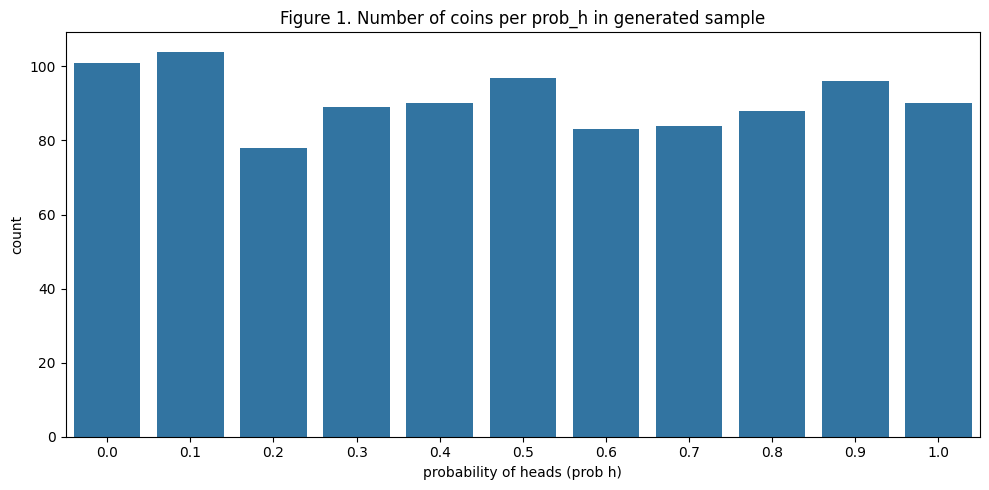

In [61]:
# random sample of n counts with probability heads between 0 and 1
n     = 1000
coins = np.random.uniform(low=0, high=1.1, size=1000)
coins = pd.DataFrame({'prob_h': np.floor(coins*10)/10})

# average probability of heads
prob_h_average = np.round(coins['prob_h'].mean(),1)
counts = pd.DataFrame(coins['prob_h'].value_counts().sort_index()).reset_index()

# visualize
plt.figure(figsize=(10, 5))
fig   = sns.barplot(x='prob_h', y='count', data = counts) #plot number of coins per prob_h
fig.set(xlabel='probability of heads (prob h)', ylabel='count')
fig.set_title('Figure 1. Number of coins per prob_h in generated sample')
plt.tight_layout()
plt.show()


Figure 1 shows the number of coins per *prob_h* in the generated sample. The coins are approximately uniformly distributed among the eleven possible *prob_h* values. Now suppose your friend randomly selects a coin from the sample and you need to guess what *prob_h* the coin has, what would you guess?



In [62]:
#select random coin
def select_coin(prob_h):
    selected = prob_h[round(np.random.rand()*(n-1))]
    return selected

coin_selected = select_coin(prob_h = coins.prob_h)

Figure 1 shows that there are approximately the same number of coins in each bin.  Consequently, the probability of drawing a coin with a specific *prob_h* should be approximately *1/11 = 0.09* as shown in the uniform probability distribution below. A uniform probability distribution is also known as **uninformative** as at this point it does not give us any information about what coin your friend might have selected.

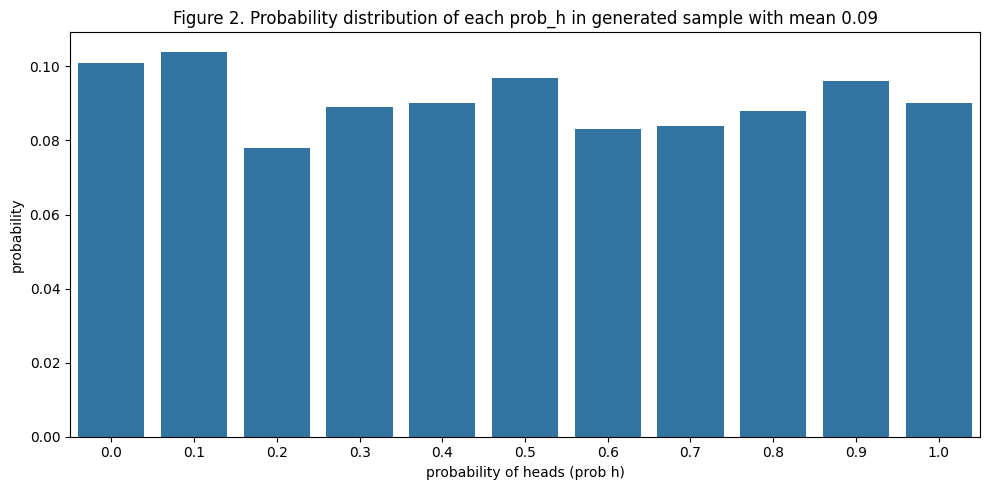

In [63]:
counts['prior'] = counts['count']/counts['count'].sum() # compute probability of each individual prob_h
mean_prob = counts['prior'].mean().round(2)

plt.figure(figsize=(10, 5))
fig   = sns.barplot(x='prob_h', y='prior', data = counts) #plot number of coins per prob_h
fig.set(xlabel='probability of heads (prob h)', ylabel='probability')
fig.set_title('Figure 2. Probability distribution of each prob_h in generated sample with mean ' + str(mean_prob))
plt.tight_layout()
plt.show()

For now, lets assume the selected coin is a fair coin with *prob_h = 0.5*. How certain are you of the coin being fair? As one in eleven coins are actually fair in the sample, you could say the coin is fair with a probability of 0.09. Now lets flip the coin a few times and see what happens.

In [68]:
def flip_coin(selected):
    return 'Heads' if np.random.random() < selected else 'Tails'

for i in range(0,5):
    print(flip_coin(selected = coin_selected))

Heads
Tails
Heads
Heads
Heads


How surprised are you with this outcome assuming the coin is fair? How does this change your certainty about the coin being fair?

The outcomes of the coin flips can be seen as new evidence and might change the degree of certainty with which you believe the coin is fair. For example, throwing heads five times in a row with a fair coin would be very surprising and therefore may decrease your certainty about the coin being fair. Bayesian inference is essentially adjusting the degree of certainty of your believes based on new evidence: if the evidence is very surprising given your believes the degree of certainty decreases while it increases if the evidence is not surprising given your believes.

Let's flip the coin and use Bayesian inference to update the degree of belief we have in the coin being fair.

In [69]:
outcome = flip_coin(selected = coin_selected)
print(outcome)

Heads


**Bayes theorem**:

$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$

Where $ P(B)\neq 0 $:

- \( P(A|B) \) is the conditional probability of event A given event B  (**posterior**)
- \( P(B|A) \) is the conditional probability of event B given event A (**likelihood**)
- \( P(A) \) and \( P(B) \) are the individual probabilities of event A and event B (**marginal**)

Lets fill in the formula with our example:

$P(Probh|Outcome) = \frac{P(Outcome|Probh) \cdot P(Probh)}{P(Outcome)}$

- \( P(Probh|Outcome) \) is the conditional probability of the coin being fair given the outcome  (**posterior**)
- \( P(Outcome|Probh)) \) is the conditional probability of the outcome given the coin is fair (**likelihood**)
- \( P(Probh) \) and \( P(Outcome) \) are the individual probabilities of the coin being fair and the outcome (**marginal**)

Lets do a single update based on the outcome above:

In [70]:
prob_h = 0.5 #assume the coin is fair

likelihood_outcome    = prob_h if outcome == 'heads' else (1 - prob_h)
prior_fair            = counts[counts['prob_h'] == prob_h]['prior'].values[0]
marginal_outcome      = np.sum(counts['prob_h'] * counts['prior'])

posterior_fair        = (prior_fair * likelihood_outcome) / marginal_outcome
print("Original belief (prior): " + str(prior_fair))
print("Updated belief (posterior): " + str(posterior_fair))

Original belief (prior): 0.097
Updated belief (posterior): 0.09845716605765328


Of course a single update form a single coin flip is not going to provide much information about whether the coin is fair or not. So let's do a simulation where we flip the coin 10 times and apply Bayesian Inference to update our degree of belief. Figure 3 shows the probability distribution after 10 iterations of updating.




In [71]:
# function to update belief
def update_belief(outcome, prob_h, prior):
    if outcome == "Heads":
        likelihood = prob_h
    else:
        likelihood = 1 - prob_h

    unnormalized_posterior = prior * likelihood
    marginal = unnormalized_posterior.sum()
    post = unnormalized_posterior / marginal

    return post

The resulting figure 3 shows the probability distribution after 10 iterations of updating. Change *n* to see what different number of updates does to the resulting probability distribution. Do you know the prob_h of the selected coin?

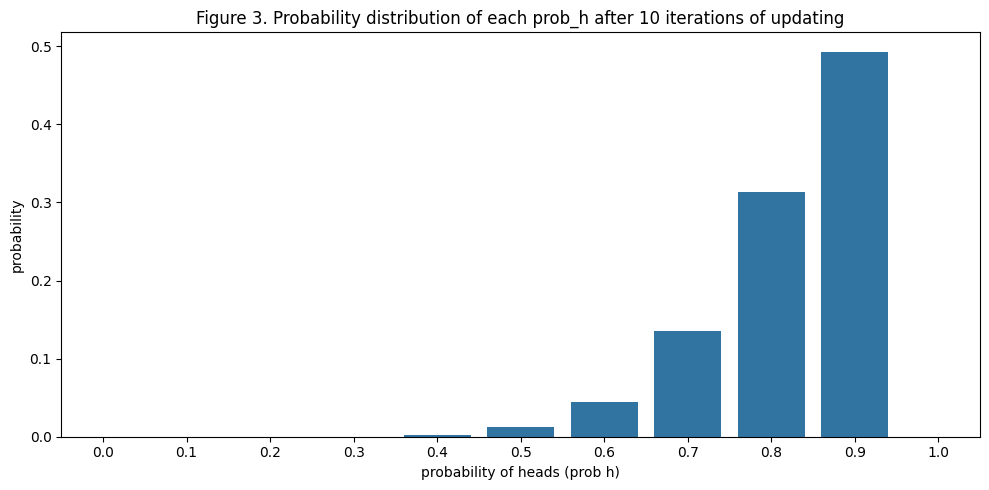

In [72]:
# 10 iterations of updating
n = 10
res = dict()
res[0] = counts['prior'] #first prior

for i in range(n):

    #flip coin
    throw_outcome = flip_coin(coin_selected)
    #update belief
    posterior = update_belief(throw_outcome, counts['prob_h'], res[i])
    #set updated belief as prior for next round
    res[i+1] = posterior


result = pd.DataFrame(res)
result['prob_h'] = counts['prob_h']
result = result.melt(id_vars = 'prob_h', var_name = 'iteration', value_name = 'value')

# visualize
plt.figure(figsize=(10, 5))
fig = sns.barplot(x='prob_h', y='value', data = result[result['iteration'] == n])
fig.set(xlabel='probability of heads (prob h)', ylabel='probability')
fig.set_title('Figure 3. Probability distribution of each prob_h after ' + str(n) + ' iterations of updating')
plt.tight_layout()
plt.tight_layout()
plt.show()


Below the exact prob_h of the selected coin is printed.

In [73]:
print("Probability of heads of selected coin: " + str(coin_selected))

Probability of heads of selected coin: 0.8


# Effect of different priors

In the above experiment you knew the prior distribution of the sample of coins was uniform. If you don't know this distribution beforehand you need to make an assumption about the prior distribution. How well the assumed distribution matches the real distribution can influence the accuracy of the results and the number of updates it takes to converge. For example, if the chosen prior distribution deviates a lot from the truth the resulting updates might be too drastic and jump to conclusions.

In the below example we repeat the experiment we did above only now we are going to start with a gaussian probability distribution centered around a probability of heads of 0.5. This is not a unrealistic assumption to make since most coins in the world are fair.

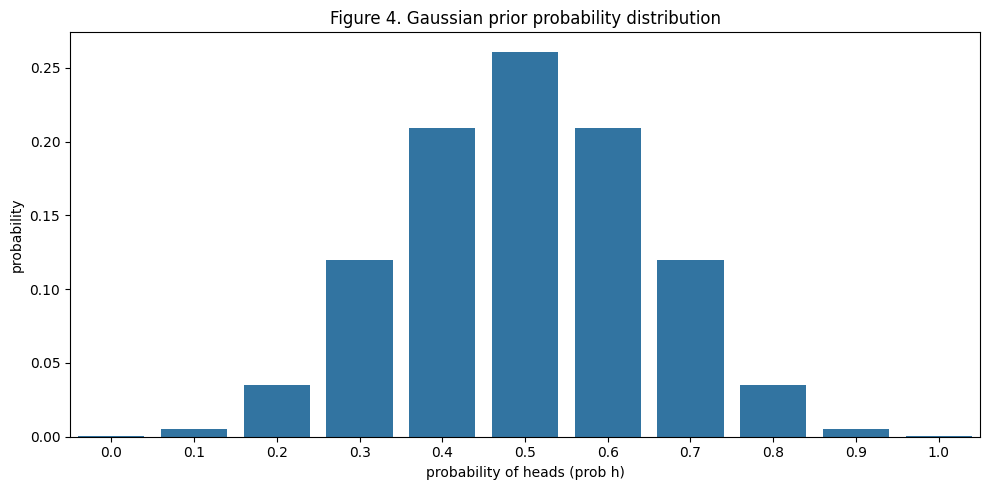

In [74]:
# select new coin
coin_selected = select_coin(prob_h = coins.prob_h)

# set gaussian probability distribution
counts['gaussian_prior'] = ([0.001, 0.020, 0.135, 0.458, 0.801, 1.000, 0.801, 0.458, 0.135, 0.020, 0.001])/np.sum([0.001, 0.020, 0.135, 0.458, 0.801, 1.000, 0.801, 0.458, 0.135, 0.020, 0.001])

plt.figure(figsize=(10, 5))
fig   = sns.barplot(x='prob_h', y='gaussian_prior', data = counts) #plot number of coins per prob_h
fig.set(xlabel='probability of heads (prob h)', ylabel='probability')
fig.set_title('Figure 4. Gaussian prior probability distribution')
plt.tight_layout()
plt.show()

Now again we do five iterations of updates on the gaussian prior and compare to the uniform prior. Notice how the gaussian prior stays centered around the midpoint of 0.5 for longer? Try a larger number of iterations and see what happens.

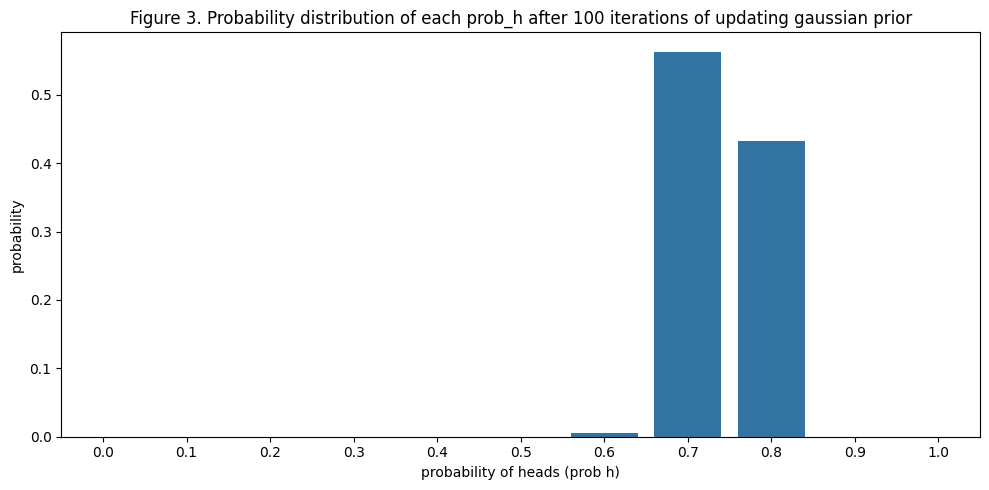

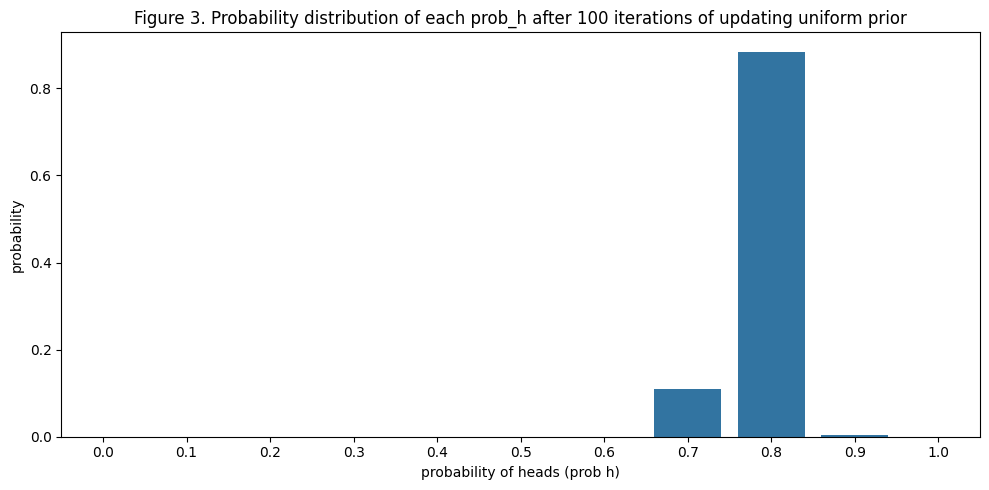

In [ ]:
# 10 iterations of updating
n = 5
res = dict()
res[0] = counts['gaussian_prior'] #first prior

for i in range(n):

    #flip coin
    throw_outcome = flip_coin(coin_selected)
    #update belief
    posterior = update_belief(throw_outcome, counts['prob_h'], res[i])
    #set updated belief as prior for next round
    res[i+1] = posterior


result = pd.DataFrame(res)
result['prob_h'] = counts['prob_h']
result = result.melt(id_vars = 'prob_h', var_name = 'iteration', value_name = 'value')

# visualize
plt.figure(figsize=(10, 5))
fig = sns.barplot(x='prob_h', y='value', data = result[result['iteration'] == n])
fig.set(xlabel='probability of heads (prob h)', ylabel='probability')
fig.set_title('Figure 3. Probability distribution of each prob_h after ' + str(n) + ' iterations of updating gaussian prior')
plt.tight_layout()
plt.tight_layout()
plt.show()

#unifrom prior
res[0] = counts['prior'] #first prior

for i in range(n):

    #flip coin
    throw_outcome = flip_coin(coin_selected)
    #update belief
    posterior = update_belief(throw_outcome, counts['prob_h'], res[i])
    #set updated belief as prior for next round
    res[i+1] = posterior


result = pd.DataFrame(res)
result['prob_h'] = counts['prob_h']
result = result.melt(id_vars = 'prob_h', var_name = 'iteration', value_name = 'value')

# visualize
plt.figure(figsize=(10, 5))
fig = sns.barplot(x='prob_h', y='value', data = result[result['iteration'] == n])
fig.set(xlabel='probability of heads (prob h)', ylabel='probability')
fig.set_title('Figure 3. Probability distribution of each prob_h after ' + str(n) + ' iterations of updating uniform prior')
plt.tight_layout()
plt.tight_layout()
plt.show()

In summary, if n is large enought the influence of the chosen prior on the outcome decreases. However, if n is small the impact of the chosen prior can be substantial.